In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv(" house_prices.csv")
df.head(10)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,45 Lac,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680 sqft,NaN,NaN
6,6,1 BHK Ready to Occupy Flat for sale Mumbra,This magnificent 1 BHK Flat is available for s...,16.5 Lac,2538.0,thane,550 sqft,Ready to Move,4 out of 5,Resale,Unfurnished,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1 BHK Ready to Occupy Flat for sale Kalwa,Creatively planned and constructed is a 1 BHK ...,60 Lac,10435.0,thane,NaN,Ready to Move,Ground out of 7,Resale,Furnished,NaN,NaN,NaN,1,NaN,NaN,NaN,575 sqft,NaN,NaN
8,8,1 BHK Ready to Occupy Flat for sale Kalwa,Discover this immaculate 1 BHK flat for sale a...,60 Lac,10000.0,thane,NaN,Ready to Move,Ground out of 2,Resale,Furnished,NaN,NaN,NaN,1,NaN,NaN,Co-operative Society,600 sqft,NaN,NaN
9,9,3 BHK Ready to Occupy Flat for sale in Pride P...,One can find this stunning 3 BHK flat for sale...,1.60 Cr,11150.0,thane,900 sqft,Ready to Move,3 out of 27,Resale,Unfurnished,East,Garden/Park,Pride Palms,3,1,1 Covered,Freehold,NaN,NaN,NaN


In [3]:
df.dtypes

Index                  int64
Title                    str
Description              str
Amount(in rupees)        str
Price (in rupees)    float64
location                 str
Carpet Area              str
Status                   str
Floor                    str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Society                  str
Bathroom                 str
Balcony                  str
Car Parking              str
Ownership                str
Super Area               str
Dimensions           float64
Plot Area            float64
dtype: object

In [5]:
# Clean price-related columns
df['Amount(in rupees)'] = df['Amount(in rupees)'].replace(r'[^\d.]', '', regex=True)
df['Amount(in rupees)'] = pd.to_numeric(df['Amount(in rupees)'], errors='coerce')

df['Price (in rupees)'] = df['Price (in rupees)'].replace(r'[^\d.]', '', regex=True)
df['Price (in rupees)'] = pd.to_numeric(df['Price (in rupees)'], errors='coerce')

In [6]:
# Clean area-related columns
area_columns = ['Carpet Area', 'Super Area', 'Plot Area']

for col in area_columns:
    df[col] = df[col].replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
numeric_cols = ['Bathroom', 'Balcony', 'Car Parking']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  177847 non-null  float64
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  float64
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186668 non-null  float64
 15  Balcony            138574 non-null  float64
 16  Car Parking  

In [9]:
df.isna().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)      9684
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                863
Balcony               48957
Car Parking          187531
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [10]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount(in rupees)'] = np.nan
df_missing.isna().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)      9690
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                863
Balcony               48957
Car Parking          187531
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [12]:
df_missing.head(10)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",NaN,6000.0,thane,500.0,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,NaN,13799.0,thane,473.0,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,NaN,NaN,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,NaN,17500.0,thane,779.0,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,NaN,NaN,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,NaN,NaN,thane,530.0,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",NaN,18824.0,thane,635.0,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,NaN,NaN,Co-operative Society,NaN,NaN,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,NaN,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1.0,1.0,NaN,Co-operative Society,680.0,NaN,NaN
6,6,1 BHK Ready to Occupy Flat for sale Mumbra,This magnificent 1 BHK Flat is available for s...,16.5,2538.0,thane,550.0,Ready to Move,4 out of 5,Resale,Unfurnished,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1 BHK Ready to Occupy Flat for sale Kalwa,Creatively planned and constructed is a 1 BHK ...,60.0,10435.0,thane,NaN,Ready to Move,Ground out of 7,Resale,Furnished,NaN,NaN,NaN,1.0,NaN,NaN,NaN,575.0,NaN,NaN
8,8,1 BHK Ready to Occupy Flat for sale Kalwa,Discover this immaculate 1 BHK flat for sale a...,60.0,10000.0,thane,NaN,Ready to Move,Ground out of 2,Resale,Furnished,NaN,NaN,NaN,1.0,NaN,NaN,Co-operative Society,600.0,NaN,NaN
9,9,3 BHK Ready to Occupy Flat for sale in Pride P...,One can find this stunning 3 BHK flat for sale...,1.6,11150.0,thane,900.0,Ready to Move,3 out of 27,Resale,Unfurnished,East,Garden/Park,Pride Palms,3.0,1.0,NaN,Freehold,NaN,NaN,NaN


In [13]:
df_removed = df_missing.dropna()
df_removed.shape

(0, 21)

In [14]:
df_removed.isna().sum()

Index                0
Title                0
Description          0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Society              0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Super Area           0
Dimensions           0
Plot Area            0
dtype: int64

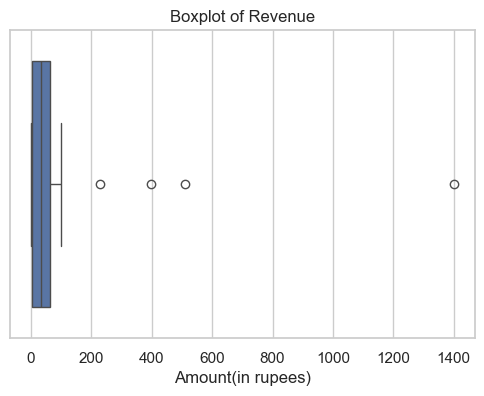

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount(in rupees)'])
plt.title("Boxplot of Revenue")
plt.show()

In [16]:
Q1 = df['Amount(in rupees)'].quantile(0.25)
Q3 = df['Amount(in rupees)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount(in rupees)'] < lower) | (df['Amount(in rupees)'] > upper)]
outliers.head(15)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
174894,174894,2 BHK Ready to Occupy Flat for sale Kachna Road,"Kachna Road, Raipur has an attractive 2 BHK Fl...",396.75,3450000.0,raipur,920.0,Ready to Move,2 out of 2,New Property,Unfurnished,East,"Garden/Park, Pool, Main Road",NaN,2.0,2.0,NaN,Freehold,NaN,NaN,NaN
175013,175013,2 BHK Ready to Occupy Flat for sale in Chaitan...,"This lovely 2 BHK Flat in Saddu, Raipur is up ...",229.80,2669100.0,raipur,750.0,Ready to Move,2 out of 9,New Property,Unfurnished,East,"Garden/Park, Main Road",Chaitanya Greens,2.0,1.0,NaN,Freehold,NaN,NaN,NaN
176536,176536,3 BHK Ready to Occupy Flat for sale Hill Cart ...,This ready to move-in 3 BHK flat is available ...,510.04,4041600.0,siliguri,970.0,Ready to Move,1 out of 4,New Property,Unfurnished,North,Main Road,NaN,2.0,1.0,NaN,Freehold,NaN,NaN,NaN
181234,181234,3 BHK Ready to Occupy Flat for sale in Nest Ha...,Have a look at this immaculate 3 BHK flat for ...,1400.30,6700000.0,vadodara,1252.0,Ready to Move,5 out of 9,New Property,Unfurnished,NaN,NaN,Nest Harmony,3.0,5.0,NaN,NaN,NaN,NaN,NaN


In [17]:
df_no_outliers = df[(df['Amount(in rupees)'] >= lower) & (df['Amount(in rupees)'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (187531, 21)
After removing outliers:  (177843, 21)


In [19]:
df[['Amount(in rupees)', 'Price (in rupees)']].head()

,Amount(in rupees),Price (in rupees)
0,42.0,6000.0
1,98.0,13799.0
2,1.4,17500.0
3,25.0,NaN
4,1.6,18824.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Amount(in rupees)', 'Price (in rupees)']].copy()

df_scaled[['Amount(in rupees)', 'Price (in rupees)']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Amount(in rupees),Price (in rupees)
0,0.029300,0.000896
1,0.069320,0.002060
2,0.000286,0.002612
3,0.017151,NaN
4,0.000429,0.002810
